In [ ]:

horizon_length = 16
num_envs = 24576
csv_list = [
    "/home/mil/shitanda/CPO_NeurIPS2025/figure_rebbuttal_0728/2_result/3/run_data/AllegroKukaReorientation/0725-1-0.001-1-0.05-0-0-5class-plot_w_24576envs_mixed_expl_learn_param_lf_1p_30_07_07h01m19s_seed4/runs",
    "/home/mil/shitanda/CPO_NeurIPS2025/figure_rebbuttal_0728/2_result/3/run_data/AllegroKukaReorientation/0725-1-0.001-1-0.1-0-0-5class-plot_w_24576envs_mixed_expl_learn_param_lf_1p_30_07_07h01m19s_seed4/runs",
    "/home/mil/shitanda/CPO_NeurIPS2025/figure_rebbuttal_0728/2_result/3/run_data/AllegroKukaReorientation/0725-1-0.001-1-0.2-0-0-5class-plot_w_24576envs_mixed_expl_learn_param_lf_1p_30_07_07h01m19s_seed4/runs",
    "/home/mil/shitanda/CPO_NeurIPS2025/figure_rebbuttal_0728/2_result/3/run_data/AllegroKukaReorientation/0725-1-0.001-1-0.5-0-0-5class-plot_w_24576envs_mixed_expl_learn_param_lf_1p_30_07_07h01m20s_seed4/runs",
    "/home/mil/shitanda/CPO_NeurIPS2025/figure_rebbuttal_0728/2_result/3/run_data/AllegroKukaReorientation/0725-SAPG-24576-plot_w_24576envs_mixed_expl_learn_param_lf_1p_30_07_07h02m42s_seed4/runs",
]



title_list = [
    "KL 0.05",
    "KL 0.1",
    "KL 0.2",
    "KL 0.5",
    "SAPG",
]

target_steps = [5e9]


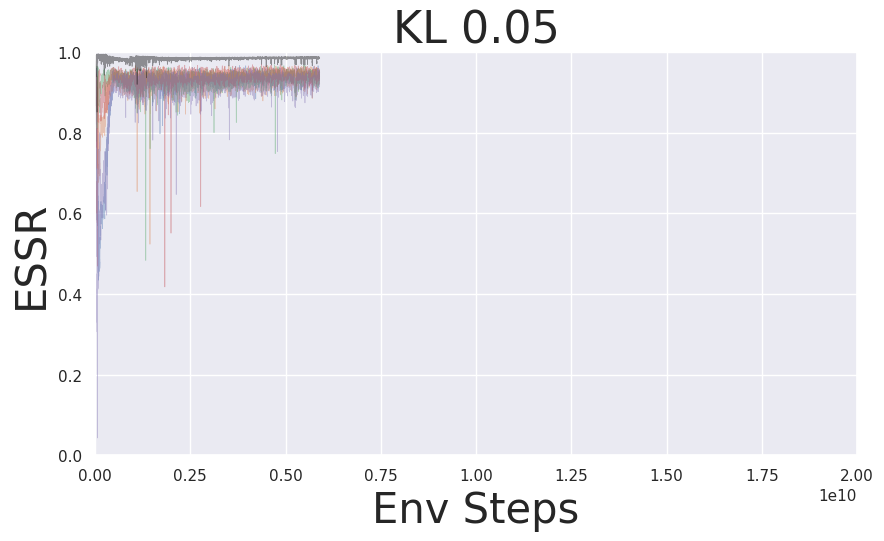

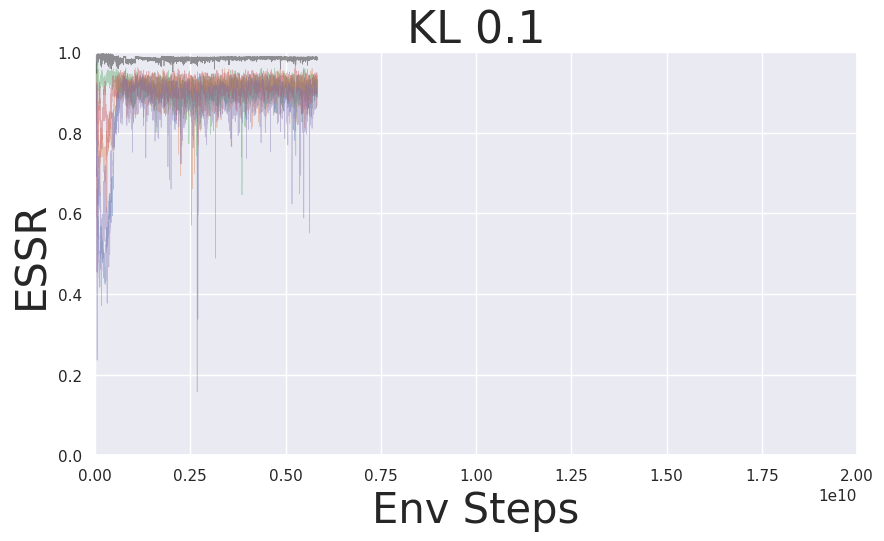

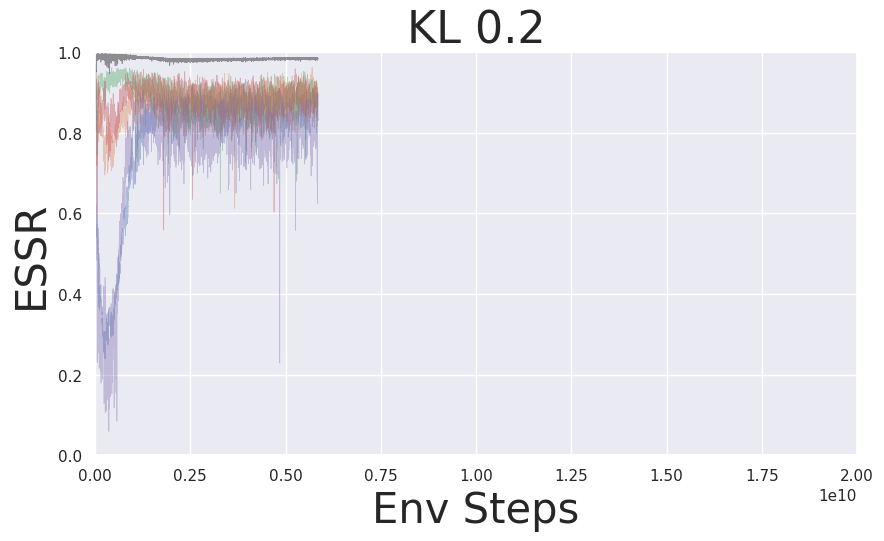

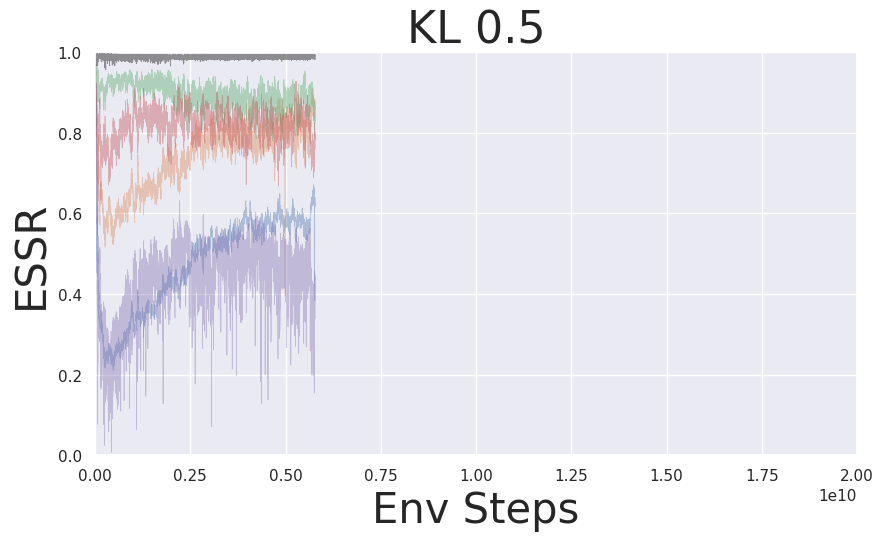

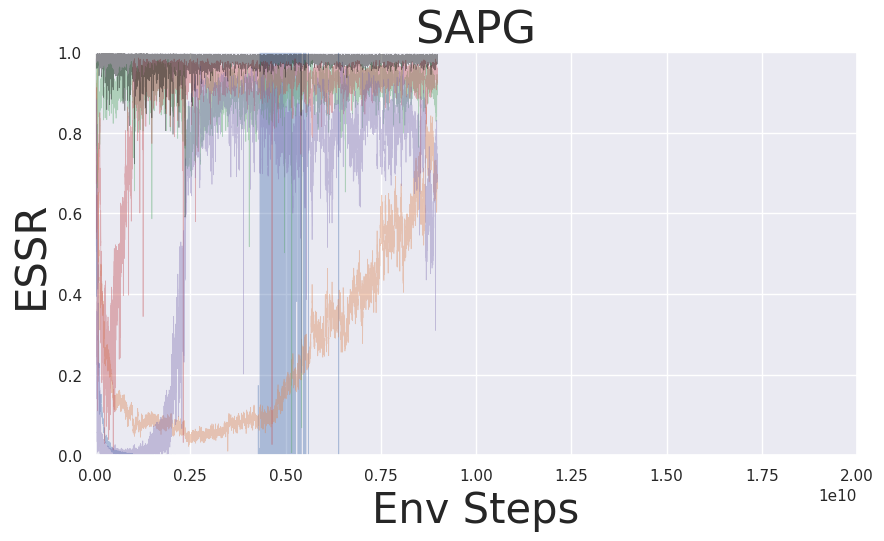

Target Step: 5000000000.0
KL 0.05: [0.93391359 0.94215691 0.93295074 0.94068801 0.93769026 0.98591578]
KL 0.05, overall: [0.94231498]
KL 0.1: [0.88668263 0.92585146 0.91909945 0.91979325 0.91682154 0.98408288]
KL 0.1, overall: [0.92175853]
KL 0.2: [0.83612084 0.90050292 0.89539075 0.86942744 0.84535241 0.98399329]
KL 0.2, overall: [0.88346595]
KL 0.5: [0.57636118 0.83236814 0.8934238  0.7693606  0.50957727 0.99045229]
KL 0.5, overall: [0.71954459]
SAPG: [1.52587891e+03 1.54770315e-01 9.26900804e-01 9.28485036e-01
 8.38804364e-01 9.85952139e-01]
SAPG, overall: [0.38327134]


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import seaborn as sns
import numpy as np
import os


def plot_ESSR(csv_path, title, horizon_length, num_envs):
    """
    CSVファイルからIS比率を読み込み、グラフをプロットする関数
    """
    sns.set()
    # CSVファイルの読み込み
    agent_data = pd.read_csv(os.path.join(csv_path, "agent_ess.csv"))
    overall_data = pd.read_csv(os.path.join(csv_path, "overall_ess_path.csv"))
    
    # データをNumPy配列に変換
    data_numpy = agent_data.to_numpy()
    overall_numpy = overall_data.to_numpy()
    

    # グラフの作成
    plt.figure(figsize=(9, 6))
    
    plt.xlabel("Env Steps", fontsize=30)
    plt.ylabel("ESSR", fontsize=30)
    plt.title(title, fontsize=32)
    plt.grid(True)
    plt.xlim(0, 2e10)
    plt.ylim(0, 1)  # Allegro Hand

    plt.tight_layout(rect=[0, 0.07, 1, 1])

    # N steps x 6のデータなので、6つの線をプロット
    for i in range(5):
        is_ratio = data_numpy[:, i] 
        x_steps = np.arange(len(is_ratio)) * horizon_length * num_envs  # 1Mステップごとにプロット
        plt.plot(x_steps, is_ratio, label=f"ESS {i+1}", linewidth=0.5, alpha=0.4)
    
    # 6個目(Leader自身のESSR)は特別な色でプロット
    is_ratio_leader = data_numpy[:, 5]
    x_steps_leader = np.arange(len(is_ratio_leader)) * horizon_length * num_envs
    plt.plot(x_steps_leader, is_ratio_leader, label="ESSR Leader", linewidth=0.5, color='black', alpha=0.4)
    
    
    
    #plt.legend(fontsize=20, loc='upper left')
    
    plt.show()

for csv_path, title in zip(csv_list, title_list):
    plot_ESSR(csv_path, title, horizon_length, num_envs)
    
# target stepでのIS比率をプリント
for target_step in target_steps:
    print(f"Target Step: {target_step}")
    for csv_path, title in zip(csv_list, title_list):
        csv_data = pd.read_csv(os.path.join(csv_path, "agent_ess.csv"))
        data_numpy = csv_data.to_numpy()
        overall_data = pd.read_csv(os.path.join(csv_path, "overall_ess_path.csv"))
        overall_numpy = overall_data.to_numpy()
        # 対象のステップに最も近いインデックスを取得
        # env stepをiteration stepに変換
        iteration_index = int(target_step // (horizon_length * num_envs))
        
        # IS比率を取得
        is_ratio = data_numpy[iteration_index]  # 1列目はEnv Stepsなので、2列目以降を使用
        overall_ratio = overall_numpy[iteration_index]  # 1列目はEnv Stepsなので、2列目以降を使用
        
        print(f"{title}: {is_ratio}")
        print(f"{title}, overall: {overall_ratio}")
    


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import seaborn as sns
import numpy as np

def plot_is_ratio_error(csv_path, title, horizon_length, num_envs):
    """
    CSVファイルからIS比率を読み込み、1からの誤差をグラフでプロットする関数
    """
    # CSVファイルの読み込み
    csv_data = pd.read_csv(csv_path)
    
    # データをNumPy配列に変換
    data_numpy = csv_data.to_numpy()
    

    # グラフの作成
    plt.figure(figsize=(9, 6))
    
    plt.xlabel("Env Steps", fontsize=30)
    plt.ylabel("IS ratio Error from 1", fontsize=30)
    plt.title(title, fontsize=32)
    plt.grid(True)
    plt.xlim(0, 2e10)
    plt.ylim(0, 0.02)  # エラーの範囲に調整

    plt.tight_layout(rect=[0, 0.07, 1, 1])

    # 最初の5つのIS比率のエラーをプロット
    for i in range(5):
        is_ratio = data_numpy[:, i]
        is_error = np.abs(is_ratio - 1.0)  # 1からの絶対誤差
        x_steps = np.arange(len(is_error)) * horizon_length * num_envs
        plt.plot(x_steps, is_error, label=f"IS ratio {i+1} Error", linewidth=0.5, alpha=0.4)
    
    # 6個目(Leader自身のIS比率)のエラーは特別な色でプロット
    is_ratio_leader = data_numpy[:, 5]
    is_error_leader = np.abs(is_ratio_leader - 1.0)
    x_steps_leader = np.arange(len(is_error_leader)) * horizon_length * num_envs
    plt.plot(x_steps_leader, is_error_leader, label="IS ratio Leader Error", linewidth=0.5, color='black', alpha=0.4)
    
    #plt.legend(fontsize=20, loc='upper left')
    
    plt.show()

for csv_path, title in zip(csv_list, title_list):
    plot_is_ratio_error(csv_path, title, horizon_length, num_envs)

IsADirectoryError: [Errno 21] Is a directory: '/home/mil/shitanda/CPO_NeurIPS2025/figure_rebbuttal_0728/2_result/3/run_data/AllegroKukaReorientation/0725-1-0.001-1-0.05-0-0-5class-plot_w_24576envs_mixed_expl_learn_param_lf_1p_30_07_07h01m19s_seed4/runs'